<a href="https://colab.research.google.com/github/nidhita2/Deep-Learning/blob/ANN/ANN_A1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Solving churn modeling using ANN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import accuracy_score
#tensorflow and keras for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
# Loading the dataset
df=pd.read_csv('Churn_Modelling.csv')
df.head()
print(df.shape)
print(df.info())
print(df.describe())


(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \

In [3]:
# select input and output
x=df.iloc[:,3:-1]
y=df.iloc[:,-1]
print(x.head())
print(y.head())
print(x.shape)
print(y.shape)

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1        101348.88  
1          0               1        112542.58  
2          1               0        113931.57  
3          0               0         93826.63  
4          1               1         79084.10  
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64
(10000, 10)
(10000,)


In [4]:
# data preprocessing
from sklearn.preprocessing import LabelEncoder
gender_encoder=LabelEncoder()
geography_encoder=LabelEncoder()
x['Gender']=gender_encoder.fit_transform(x['Gender'])
x['Geography']=geography_encoder.fit_transform(x['Geography'])
x.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [5]:
# train test split of the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 10)
(2000, 10)
(8000,)
(2000,)


In [6]:
# feature scaling
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [7]:
# building ANN
ann=Sequential()
ann.add(Dense(units=6,activation='relu')) # unit represents the number of perceptrons(input)
ann.add(Dense(units=6,activation='relu')) # hidden layer
ann.add(Dense(units=1,activation='sigmoid')) # output layer


In [8]:
# complie model
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [9]:
# train
history=ann.fit(x_train,y_train,batch_size=32,epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6894 - loss: 0.6210 - val_accuracy: 0.7969 - val_loss: 0.5274
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.4939 - val_accuracy: 0.7987 - val_loss: 0.4706
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4647 - val_accuracy: 0.7987 - val_loss: 0.4499
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4518 - val_accuracy: 0.7987 - val_loss: 0.4383
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7933 - loss: 0.4450 - val_accuracy: 0.8000 - val_loss: 0.4321
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7925 - loss: 0.4414 - val_accuracy: 0.8012 - val_loss: 0.4281
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7944 - loss: 0.4391 - val_accuracy: 0.8094 - val_loss: 0.4252
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7975 - loss: 0.4373 - val_accu

In [10]:
#prediction
y_pred=ann.predict(x_test)
y_pred=(y_pred>0.5)
print(y_pred [0:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


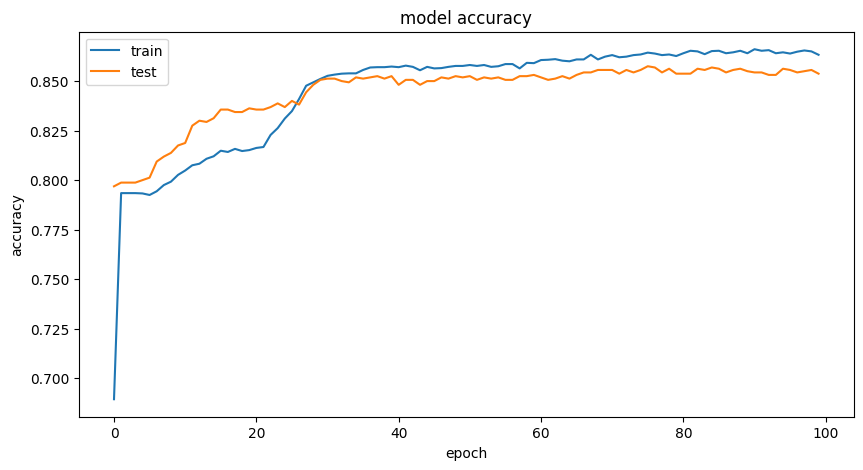

In [11]:
# accuracy graph
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Acurracy')
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')

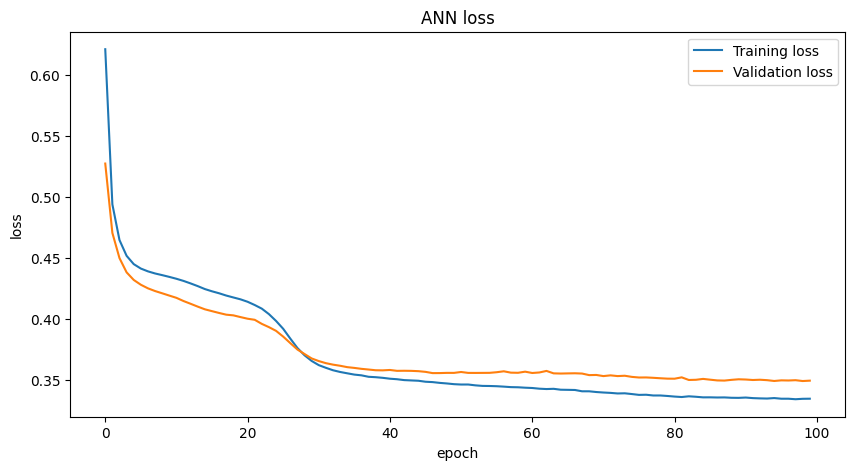

In [12]:
#loss graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('ANN loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()